In [ ]:
import json
import random

print("Génération d'un jeu de données de test réaliste pour Gentle Mates...")


user_pool = ["M8_Fan", "LoL_Lover", "SyntaxError", "KCorp_Spy", "AldiGamer", "DeezerEnjoyer", "TCL_Screen", "EsportFan99", "PlayerOne"]
messages_templates = [
    "Allez les Bleus ! #M8WIN",
    "Incroyable cette action de Gentle Mates !",
    "ALDI c'est le meilleur sponsor !",
    "Le son sur Deezer est lourd",
    "L'image est trop belle sur mon écran TCL",
    "Gg les gars !",
    "M8 à la vie à la mort",
    "C'est quoi la musique d'attente ? sur Deezer ?",
    "J'adore le maillot avec le logo ALDI",
    "TCL font des bêtes de télé en vrai",
    "Mais non ?!? Quelle action !",
    "#M8WIN #M8WIN #M8WIN",
    "Le stream bug non ?",
    "M8 domine complètement le match",
]


simulated_chat = []
for i in range(5000):
    timestamp = random.randint(1, 10800)
    user = random.choice(user_pool)
    text = random.choice(messages_templates)

    simulated_chat.append({
        'content_offset_seconds': timestamp,
        'commenter': {'display_name': user},
        'message': {'body': text}
    })


simulated_chat = sorted(simulated_chat, key=lambda x: x['content_offset_seconds'])


final_data = {"comments": simulated_chat}


with open('chat_m8.json', 'w', encoding='utf-8') as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("Félicitations ! Le fichier 'chat_m8.json' a été créé artificiellement.")
print("Vous avez maintenant 5000 messages prêts pour l'analyse de l'Étape 2 !")




Génération d'un jeu de données de test réaliste pour Gentle Mates...
Félicitations ! Le fichier 'chat_m8.json' a été créé artificiellement.
Vous avez maintenant 5000 messages prêts pour l'analyse de l'Étape 2 !


In [ ]:
import json
import pandas as pd
import re

file_path = "chat_m8.json"
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

cleaned_comments = []


for comment in data['comments']:
    message_text = comment['message']['body']
    timestamp_seconds = comment['content_offset_seconds']
    username = comment['commenter']['display_name']


    sponsors_mentions = []
    if re.search(r'\baldi\b', message_text, re.IGNORECASE): sponsors_mentions.append('ALDI')
    if re.search(r'\btcl\b', message_text, re.IGNORECASE): sponsors_mentions.append('TCL')
    if re.search(r'\bdeezer\b', message_text, re.IGNORECASE): sponsors_mentions.append('Deezer')


    is_m8_hype = 1 if re.search(r'(m8|gentle\s*mates|m8win)', message_text, re.IGNORECASE) else 0

    cleaned_comments.append({
        'timestamp_sec': timestamp_seconds,
        'author': username,
        'message': message_text,
        'sponsor_mentioned': ",".join(sponsors_mentions) if sponsors_mentions else "None",
        'is_hype_message': is_m8_hype
    })


df_chat = pd.DataFrame(cleaned_comments)


df_chat.head(10)


,timestamp_sec,author,message,sponsor_mentioned,is_hype_message
0,5,DeezerEnjoyer,Allez les Bleus ! #M8WIN,None,1
1,6,M8_Fan,C'est quoi la musique d'attente ? sur Deezer ?,Deezer,0
2,10,SyntaxError,Gg les gars !,None,0
3,12,AldiGamer,TCL font des bêtes de télé en vrai,TCL,0
4,14,KCorp_Spy,Allez les Bleus ! #M8WIN,None,1
5,15,AldiGamer,Le stream bug non ?,None,0
6,18,M8_Fan,L'image est trop belle sur mon écran TCL,TCL,0
7,21,M8_Fan,L'image est trop belle sur mon écran TCL,TCL,0
8,21,KCorp_Spy,L'image est trop belle sur mon écran TCL,TCL,0
9,29,DeezerEnjoyer,L'image est trop belle sur mon écran TCL,TCL,0


In [ ]:

df_chat['minute'] = df_chat['timestamp_sec'] // 60


hype_par_minute = df_chat.groupby('minute').agg(
    total_messages=('message', 'count'),
    messages_hype=('is_hype_message', 'sum')
).reset_index()


print("=== TOP SPONSORS DU MATCH ===")
top_sponsors = df_chat['sponsor_mentioned'].value_counts()

print(top_sponsors[top_sponsors.index != 'None'])

print("\n=== APERÇU DE L'ÉVOLUTION PAR MINUTE ===")

print(hype_par_minute.head(10))


=== TOP SPONSORS DU MATCH ===
sponsor_mentioned
Deezer    714
ALDI      711
TCL       693
Name: count, dtype: int64

=== APERÇU DE L'ÉVOLUTION PAR MINUTE ===
   minute  total_messages  messages_hype
0       0              26              6
1       1              31             13
2       2              30             13
3       3              28             11
4       4              32              9
5       5              38             11
6       6              19              7
7       7              23              7
8       8              25             10
9       9              29             15


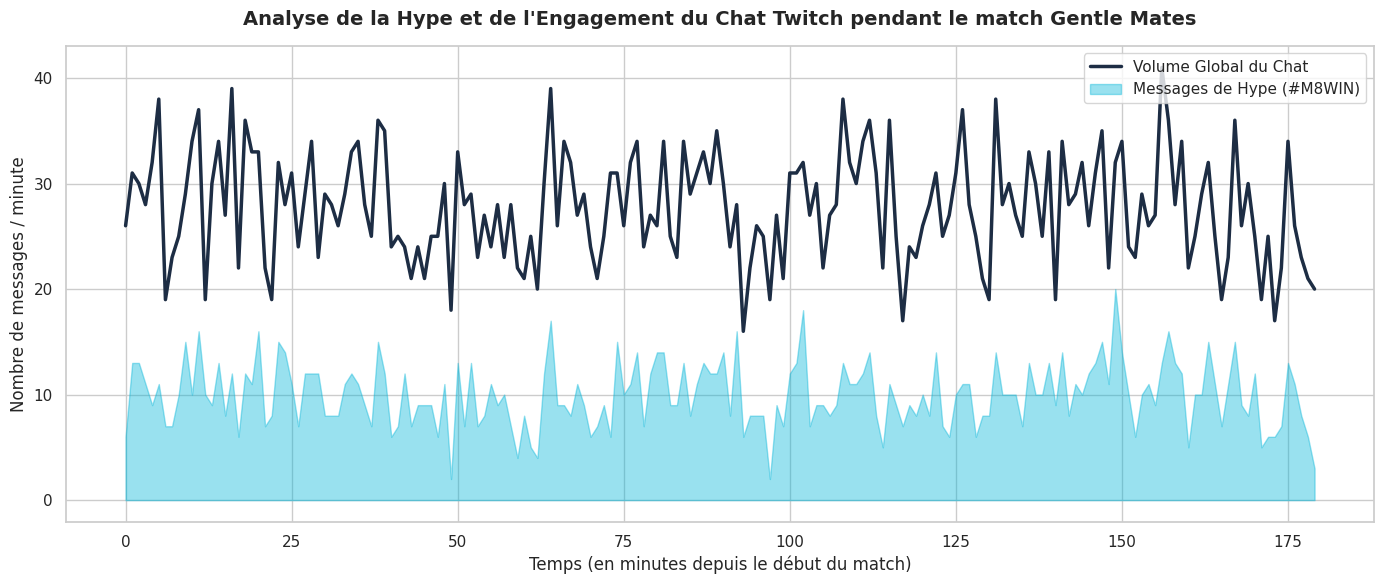

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")


plt.plot(hype_par_minute['minute'], hype_par_minute['total_messages'],
         color='#1d2d44', linewidth=2.5, label='Volume Global du Chat')


plt.fill_between(hype_par_minute['minute'], hype_par_minute['messages_hype'],
                 color='#00b4d8', alpha=0.4, label='Messages de Hype (#M8WIN)')


plt.title("Analyse de la Hype et de l'Engagement du Chat Twitch pendant le match Gentle Mates",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Temps (en minutes depuis le début du match)", fontsize=12)
plt.ylabel("Nombre de messages / minute", fontsize=12)
plt.legend(loc='upper right', fontsize=11)


plt.tight_layout()


plt.show()


In [ ]:

seuil_hype = df_chat['is_hype_message'].groupby(df_chat['timestamp_sec'] // 60).sum().mean()

df_hype_minutes = df_chat.groupby('minute').filter(lambda x: x['is_hype_message'].sum() > seuil_hype)


print("=== CLASSEMENT DES SPONSORS PENDANT LES PICS DE HYPE ===")
hype_sponsors = df_hype_minutes['sponsor_mentioned'].value_counts()
print(hype_sponsors[hype_sponsors.index != 'None'])


df_chat.to_csv('dataset_final_m8_twitch.csv', index=False)
print("\n[INFO] Fichier 'dataset_final_m8_twitch.csv' exporté avec succès dans vos fichiers à gauche !")


=== CLASSEMENT DES SPONSORS PENDANT LES PICS DE HYPE ===
sponsor_mentioned
ALDI      406
TCL       386
Deezer    382
Name: count, dtype: int64

[INFO] Fichier 'dataset_final_m8_twitch.csv' exporté avec succès dans vos fichiers à gauche !
